In [2]:
import pandas as pd
import numpy as np
import glob
import os

In [3]:
def extract_data_after_begin(filepath):
    """
    Read a CSV file and extract the first two columns after the 'BEGIN' row.
    
    Parameters:
    -----------
    filepath : str
        Path to the CSV file
    
    Returns:
    --------
    pandas.DataFrame with first two columns, or None if 'BEGIN' not found
    """
    # Read file and find the BEGIN row
    with open(filepath, 'r') as f:
        lines = f.readlines()
    
    # Find the index of the BEGIN row
    begin_idx = None
    for i, line in enumerate(lines):
        if line.strip() == 'BEGIN':
            begin_idx = i
            break
    
    if begin_idx is None:
        print(f"Warning: 'BEGIN' not found in {filepath}")
        return None
    
    # Read the data starting after BEGIN
    df = pd.read_csv(filepath, skiprows=begin_idx + 1, header=None, usecols=[0, 1])
    df.columns = ['Column1', 'Column2']
    
    return df

In [4]:
# Get all CSV files in the current folder
folder_path = '../data/channel_characterization_128ch'
csv_files = sorted(glob.glob(os.path.join(folder_path, '*.csv')), 
                   key=lambda x: int(os.path.basename(x).split('_')[1].split('.')[0]) 
                   if '_' in os.path.basename(x) else 0)

print(f"Found {len(csv_files)} CSV files")
print(f"First few files: {[os.path.basename(f) for f in csv_files[:5]]}")

Found 128 CSV files
First few files: ['File_1.csv', 'File_2.csv', 'File_3.csv', 'File_4.csv', 'File_5.csv']


In [35]:
# Extract data from all CSV files
all_data = {}

for csv_file in csv_files:
    filename = os.path.basename(csv_file)
    df = extract_data_after_begin(csv_file)
    if df is not None:
        all_data[filename] = df

print(f"Successfully extracted data from {len(all_data)} files")

Successfully extracted data from 128 files


In [40]:
# Display sample data from first file
if all_data:
    first_file = list(all_data.keys())[0]
    print(f"Sample data from {first_file}:")
    print(all_data[first_file].head(10))
    print(f"\nShape: {all_data[first_file].shape}")

Sample data from File_1.csv:
  Column1     Column2
0  292799 -117.861565
1  292809 -119.310760
2  292819 -119.307671
3  292829 -119.748375
4  292839 -119.086937
5  292849 -117.704910
6  292859 -118.577835
7  292869 -117.475121
8  292879 -119.426819
9  292889 -120.761978

Shape: (1002, 2)


In [41]:
# Combine all data into a single DataFrame with file names as column prefixes
# Each file contributes two columns: Column1 (shared) and Column2 (unique per file)

if all_data:
    # Use the first file's Column1 as the reference (assuming all files have same Column1 values)
    first_key = list(all_data.keys())[0]
    combined_df = pd.DataFrame()
    combined_df['Column1'] = all_data[first_key]['Column1']
    
    for filename, df in all_data.items():
        file_label = filename.replace('.csv', '')
        combined_df[file_label] = df['Column2'].values
    
    print(f"Combined DataFrame shape: {combined_df.shape}")
    combined_df.head()

Combined DataFrame shape: (1002, 129)


/var/folders/cd/s_qhw6j93_v84snv8j9x26080000gn/T/ipykernel_11514/555159212.py:12: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  combined_df[file_label] = df['Column2'].values
/var/folders/cd/s_qhw6j93_v84snv8j9x26080000gn/T/ipykernel_11514/555159212.py:12: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  combined_df[file_label] = df['Column2'].values
/var/folders/cd/s_qhw6j93_v84snv8j9x26080000gn/T/ipykernel_11514/555159212.py:12: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.inse

In [59]:
# Extract noise floor at frequency = 292839 Hz
noise_floor_freq = 292839

# Remove rows where Column1 contains non-numeric values (like "END")
combined_df = combined_df[combined_df['Column1'] != 'END'].copy()

# Convert Column1 to numeric
combined_df['Column1'] = pd.to_numeric(combined_df['Column1'])

print(f"Looking for frequency: {noise_floor_freq}")
print(f"Column1 dtype: {combined_df['Column1'].dtype}")
print(f"Column1 range: {combined_df['Column1'].min()} to {combined_df['Column1'].max()}")

# Find the row in combined_df where Column1 equals noise_floor_freq
noise_row = combined_df[combined_df['Column1'] == noise_floor_freq]

if len(noise_row) == 0:
    print(f"\nWarning: Frequency {noise_floor_freq} not found exactly")
    # Find closest frequency
    closest_idx = (combined_df['Column1'] - noise_floor_freq).abs().idxmin()
    noise_row = combined_df.loc[[closest_idx]]
    print(f"Using closest frequency: {noise_row['Column1'].values[0]}")
else:
    print(f"Found exact frequency: {noise_floor_freq}")

# Extract noise floor values for each channel
noise_floor_data = []
for filename in all_data.keys():
    file_label = filename.replace('.csv', '')
    channel_num = int(filename.split('_')[1].split('.')[0])
    noise_floor_value = noise_row[file_label].values[0]
    noise_floor_data.append({
        'Channel': channel_num,
        'Noise_Floor': noise_floor_value
    })

noise_floor_df = pd.DataFrame(noise_floor_data).sort_values('Channel')
print(f"\nNoise floor values extracted at frequency {noise_row['Column1'].values[0]} Hz")
print(noise_floor_df.head(10))

Looking for frequency: 292839
Column1 dtype: int64
Column1 range: 292799 to 302799
Found exact frequency: 292839

Noise floor values extracted at frequency 292839 Hz
   Channel  Noise_Floor
0        1  -119.086937
1        2  -117.253372
2        3  -119.002800
3        4  -117.408188
4        5  -119.069954
5        6  -119.831245
6        7  -117.726936
7        8  -117.660164
8        9  -117.996155
9       10  -121.270615


   Channel     Signal  Noise_Floor
0        1 -83.872185  -119.086937
1        2 -83.517593  -117.253372
2        3 -83.673111  -119.002800
3        4 -83.794312  -117.408188
4        5 -83.618362  -119.069954
5        6 -83.447311  -119.831245
6        7 -83.922577  -117.726936
7        8 -83.580116  -117.660164
8        9 -83.525978  -117.996155
9       10 -83.745560  -121.270615


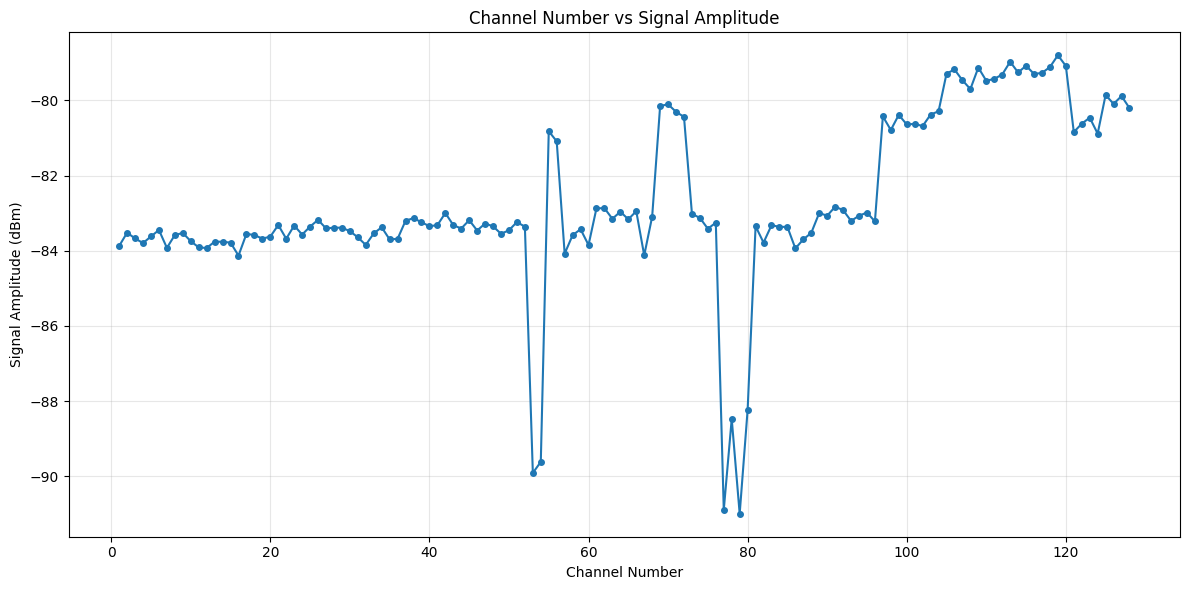

In [60]:
import matplotlib.pyplot as plt

# Extract channel numbers and find max of Column2 for each file
channel_numbers = []
max_values = []

for filename, df in all_data.items():
    # Extract channel number from filename (e.g., File_2.csv -> 2)
    channel_num = int(filename.split('_')[1].split('.')[0])
    max_val = df['Column2'].max()
    
    channel_numbers.append(channel_num)
    max_values.append(max_val)

# Create a DataFrame for easy sorting and viewing
results_df = pd.DataFrame({
    'Channel': channel_numbers,
    'Signal': max_values
}).sort_values('Channel')

# Merge with noise floor data
results_df = results_df.merge(noise_floor_df, on='Channel', how='left')

print(results_df.head(10))

# Plot channel number vs max value
plt.figure(figsize=(12, 6))
plt.plot(results_df['Channel'], results_df['Signal'], 'o-', markersize=4)
plt.xlabel('Channel Number')
plt.ylabel('Signal Amplitude (dBm)')
plt.title('Channel Number vs Signal Amplitude')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

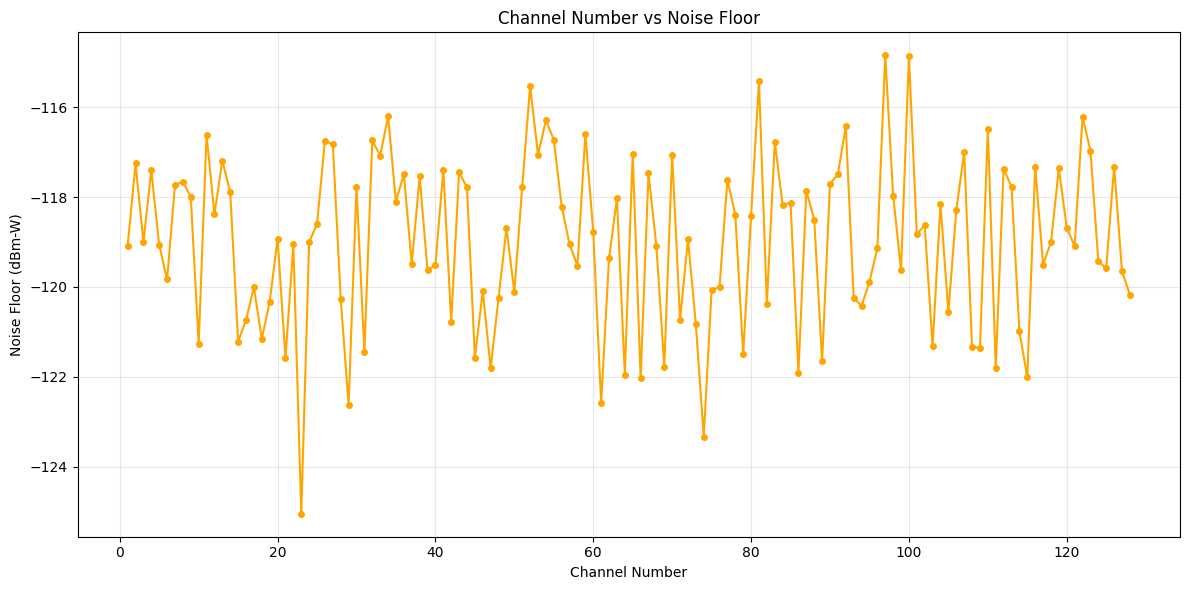

In [77]:
# Plot channel number vs noise floor
plt.figure(figsize=(12, 6))
plt.plot(noise_floor_df['Channel'], noise_floor_df['Noise_Floor'], 'o-', markersize=4, color='orange')
plt.xlabel('Channel Number')
plt.ylabel('Noise Floor (dBm-W)')
plt.title('Channel Number vs Noise Floor')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Noise floor converted to noise equivalent power

First 10 channels:
   Channel  Noise_Floor  Noise_Equiv_Power_W_rtHz
0        1  -119.086937              4.097411e-11
1        2  -117.253372              5.060433e-11
2        3  -119.002800              4.137294e-11
3        4  -117.408188              4.971036e-11
4        5  -119.069954              4.105430e-11
5        6  -119.831245              3.760920e-11
6        7  -117.726936              4.791919e-11
7        8  -117.660164              4.828899e-11
8        9  -117.996155              4.645673e-11
9       10  -121.270615              3.186586e-11

Mean NEP: 4.255e-11 W/rtHz
Mean NEP: 0.043 nW/rtHz


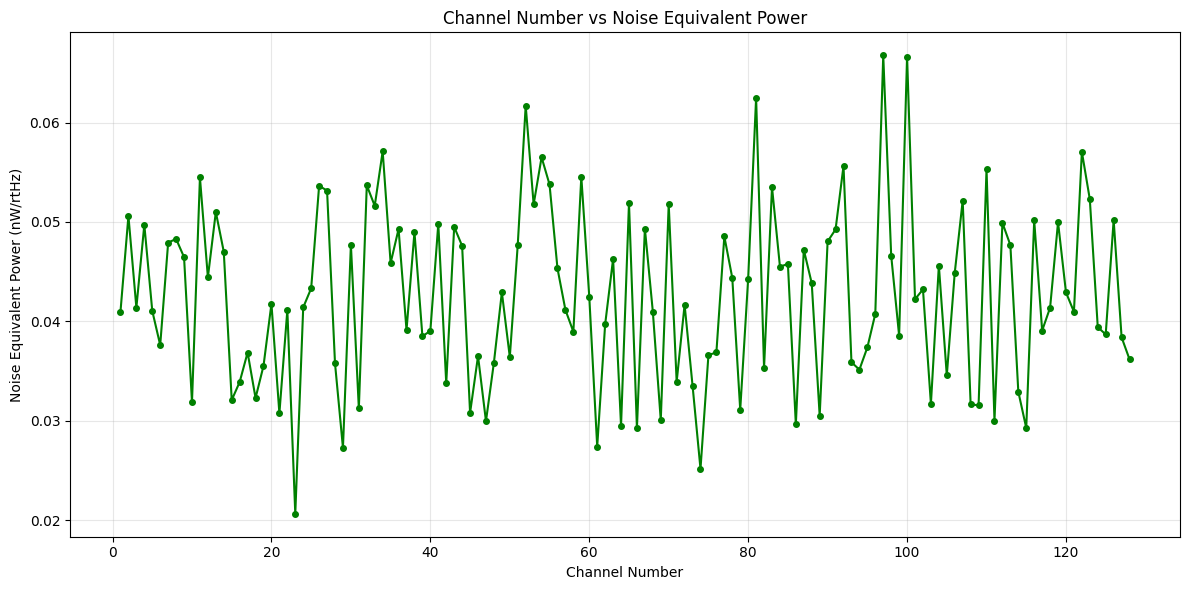

In [78]:
# Convert noise floor from dBm to noise equivalent power (W/rtHz)
RBW = 3  # Hz
R = 50  # ohm
TIA_gain = 5000  # ohm (5 kOhm)
PD_responsivity = 0.7  # A/W

# Create a copy of noise_floor_df to add conversions
noise_power_df = noise_floor_df.copy()

# Step 1: Convert dBm to Watts (power within RBW), then to power spectral density (W/Hz)
noise_power_df['Noise_W_Hz'] = 10**((noise_power_df['Noise_Floor'] - 30) / 10) / RBW

# Step 2: Calculate voltage spectral density (V/rtHz) from power spectral density
# S_v = sqrt(S_p * R)
noise_power_df['Noise_V_rtHz'] = np.sqrt(noise_power_df['Noise_W_Hz'] * R)

# Step 3: Calculate current spectral density (A/rtHz) from voltage and TIA gain
# i = V / TIA_gain
noise_power_df['Noise_A_rtHz'] = noise_power_df['Noise_V_rtHz'] / TIA_gain

# Step 4: Calculate optical NEP (W/rtHz) from current (W_optical = A / PD_responsivity)
noise_power_df['Noise_Equiv_Power_W_rtHz'] = noise_power_df['Noise_A_rtHz'] / PD_responsivity

print(f"Noise floor converted to noise equivalent power")
print(f"\nFirst 10 channels:")
print(noise_power_df[['Channel', 'Noise_Floor', 'Noise_Equiv_Power_W_rtHz']].head(10))
print(f"\nMean NEP: {noise_power_df['Noise_Equiv_Power_W_rtHz'].mean():.3e} W/rtHz")
print(f"Mean NEP: {noise_power_df['Noise_Equiv_Power_W_rtHz'].mean() * 1e9:.3f} nW/rtHz")

# Plot noise equivalent power vs channel number
plt.figure(figsize=(12, 6))
plt.plot(noise_power_df['Channel'], noise_power_df['Noise_Equiv_Power_W_rtHz'] * 1e9, 'o-', markersize=4, color='green')
plt.xlabel('Channel Number')
plt.ylabel('Noise Equivalent Power (nW/rtHz)')
plt.title('Channel Number vs Noise Equivalent Power')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [63]:
# Photocurrent data from MATLAB (mean in uA, stddev in uA)
ch_group = [1, 5, 9, 13, 17, 21, 25, 29, 33, 37, 41, 45, 49, 53, 57, 61, 
            65, 69, 73, 77, 81, 85, 89, 93, 97, 101, 105, 109, 113, 117, 121, 125]
mean_uA  = [3.444, 3.402, 3.388, 3.420, 3.417, 3.450, 3.470, 3.462, 3.508, 3.528, 3.400, 3.363, 
            3.433, 4.373, 3.558, 3.487, 3.465, 4.137, 3.445, 3.397, 3.389, 3.384, 3.442, 3.450, 
            4.259, 4.298, 4.784, 4.810, 4.790, 4.835, 4.370, 4.513]
stddev_uA = [0.020, 0.011, 0.013, 0.010, 0.012, 0.014, 0.024, 0.010, 0.010, 0.012, 0.014, 0.017, 
             0.033, 0.038, 0.022, 0.013, 0.011, 0.027, 0.017, 0.014, 0.013, 0.009, 0.018, 0.008, 
             0.009, 0.025, 0.025, 0.020, 0.019, 0.044, 0.026, 0.008]
nsamp = [260, 130, 120, 120, 150, 115, 120, 115, 165, 125, 120, 230, 
         165, 170, 240, 180, 220, 145, 200, 285, 430, 215, 377, 130, 
         215, 215, 130, 150, 105, 135, 150, 140]

# Verify channel groups are spaced by 4
expected_groups = list(range(1, 129, 4))
if ch_group != expected_groups:
    print(f"Warning: Channel groups are not properly spaced by 4!")
    print(f"Expected: {expected_groups}")
    print(f"Got: {ch_group}")
    ch_group = expected_groups  # Fix it
    print("Fixed to expected spacing.")
else:
    print("Channel groups verified: spacing of 4 is correct.")

# Create a DataFrame mapping each group to its values
group_df = pd.DataFrame({
    'ch_group': ch_group,
    'mean_uA': mean_uA,
    'stddev_uA': stddev_uA,
    'nsamp': nsamp
})

# Map every individual channel (1-128) to its group's mean, stddev, and nsamp
channel_photocurrent = []
for ch in range(1, 129):
    # Find which group this channel belongs to (group starts at 1, 5, 9, ...)
    group_start = ((ch - 1) // 4) * 4 + 1
    group_data = group_df[group_df['ch_group'] == group_start].iloc[0]
    channel_photocurrent.append({
        'Channel': ch,
        'Group': group_start,
        'Mean_uA': group_data['mean_uA'],
        'Stddev_uA': group_data['stddev_uA'],
        'Nsamp': group_data['nsamp']
    })

photocurrent_df = pd.DataFrame(channel_photocurrent)
print(f"Photocurrent DataFrame shape: {photocurrent_df.shape}")
print("\nFirst 10 channels:")
print(photocurrent_df.head(10))
print("\nGroup summary:")
print(group_df)

Channel groups verified: spacing of 4 is correct.
Photocurrent DataFrame shape: (128, 5)

First 10 channels:
   Channel  Group  Mean_uA  Stddev_uA  Nsamp
0        1      1    3.444      0.020  260.0
1        2      1    3.444      0.020  260.0
2        3      1    3.444      0.020  260.0
3        4      1    3.444      0.020  260.0
4        5      5    3.402      0.011  130.0
5        6      5    3.402      0.011  130.0
6        7      5    3.402      0.011  130.0
7        8      5    3.402      0.011  130.0
8        9      9    3.388      0.013  120.0
9       10      9    3.388      0.013  120.0

Group summary:
    ch_group  mean_uA  stddev_uA  nsamp
0          1    3.444      0.020    260
1          5    3.402      0.011    130
2          9    3.388      0.013    120
3         13    3.420      0.010    120
4         17    3.417      0.012    150
5         21    3.450      0.014    115
6         25    3.470      0.024    120
7         29    3.462      0.010    115
8         33    3.50

In [64]:
# Channel numbers and mean photocurrent only
channel_mean_df = photocurrent_df[['Channel', 'Mean_uA']].copy()
channel_mean_df

,Channel,Mean_uA
0,1,3.444
1,2,3.444
2,3,3.444
3,4,3.444
4,5,3.402
...,...,...
123,124,4.370
124,125,4.513
125,126,4.513
126,127,4.513


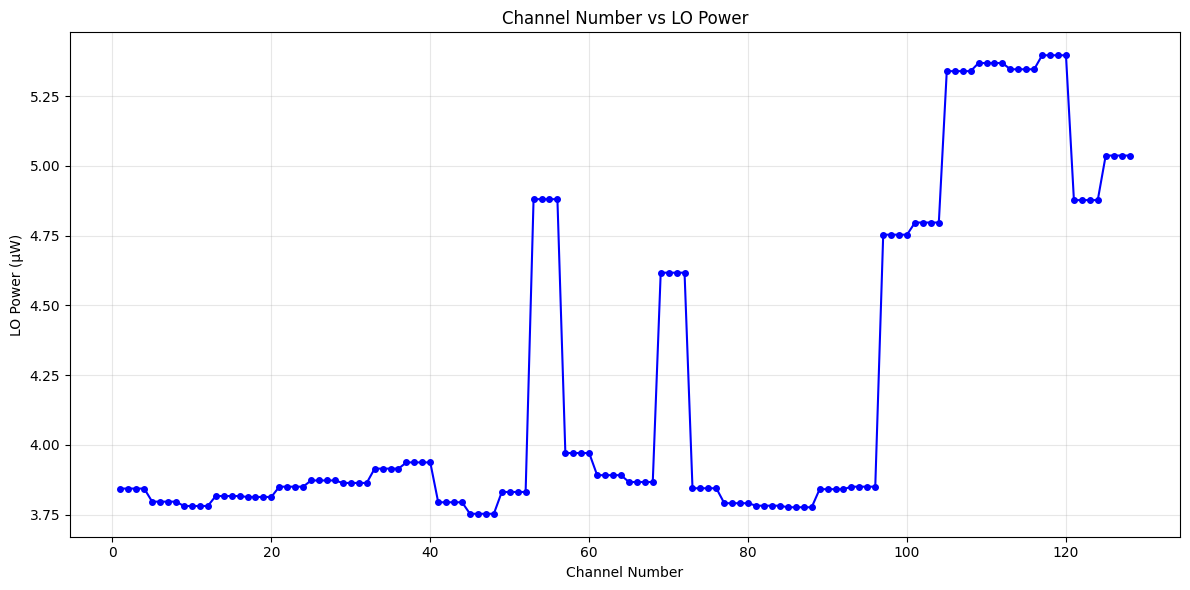

,Channel,Mean_uA,Mean_uW
0,1,3.444,3.843750
1,2,3.444,3.843750
2,3,3.444,3.843750
3,4,3.444,3.843750
4,5,3.402,3.796875
...,...,...,...
123,124,4.370,4.877232
124,125,4.513,5.036830
125,126,4.513,5.036830
126,127,4.513,5.036830


In [67]:
LO_split = 128
tap_split = 1/100
pd_responsivity = 0.7  # Example responsivity in A/W
channel_mean_df['Mean_uW'] = channel_mean_df['Mean_uA']/pd_responsivity/LO_split/tap_split

# Plot channel vs mean uW (LO power)
plt.figure(figsize=(12, 6))
plt.plot(channel_mean_df['Channel'], channel_mean_df['Mean_uW'], 'o-', markersize=4, color='blue')
plt.xlabel('Channel Number')
plt.ylabel('LO Power (µW)')
plt.title('Channel Number vs LO Power')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

channel_mean_df

Optical Sensitivity of Balanced Homodyne Detectors
   Channel   Mean_uW  Noise_Floor  Sensitivity_W_rtHz  Sensitivity_fW_rtHz
0        1  3.843750  -119.086937        1.091953e-16             0.109195
1        2  3.843750  -117.253372        1.665560e-16             0.166556
2        3  3.843750  -119.002800        1.113314e-16             0.111331
3        4  3.843750  -117.408188        1.607233e-16             0.160723
4        5  3.796875  -119.069954        1.109765e-16             0.110976
5        6  3.796875  -119.831245        9.313262e-17             0.093133
6        7  3.796875  -117.726936        1.511934e-16             0.151193
7        8  3.796875  -117.660164        1.535359e-16             0.153536
8        9  3.781250  -117.996155        1.426927e-16             0.142693
9       10  3.781250  -121.270615        6.713605e-17             0.067136

Mean sensitivity: 1.135e-16 W/rtHz (0.11 fW/rtHz)
Std sensitivity: 4.793e-17 W/rtHz (0.05 fW/rtHz)


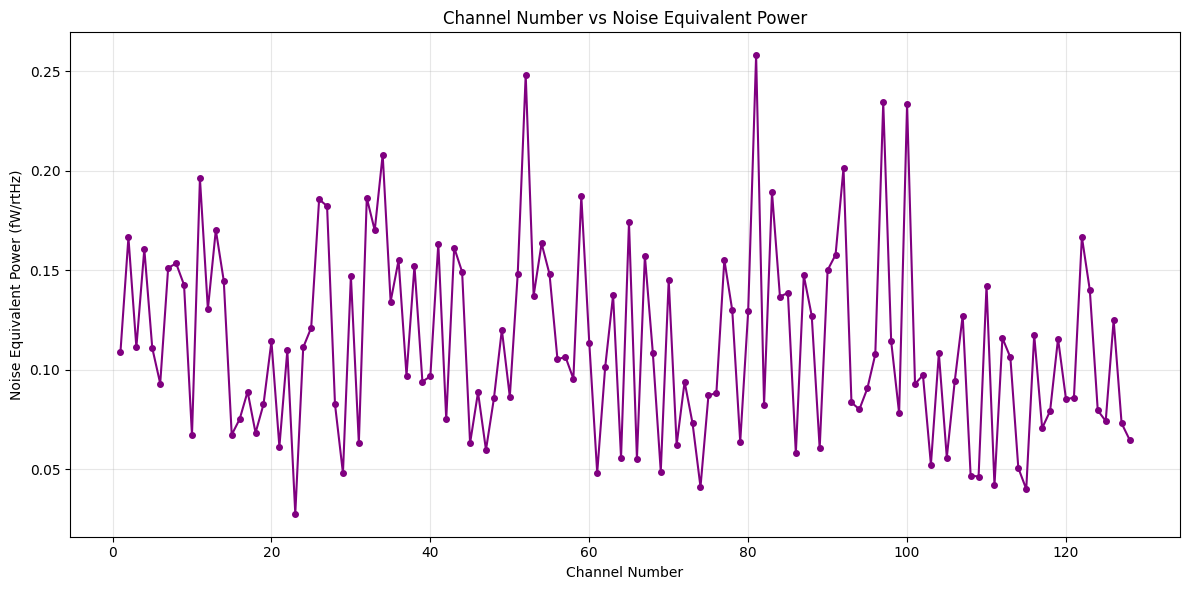

In [80]:
# Calculate optical sensitivity of each balanced homodyne detector
# Sensitivity = signal power required to achieve SNR=1 at the noise floor with LO

# Parameters
R = 50  # ohm (load resistance)
RBW = 3  # Hz (resolution bandwidth)
TIA_gain = 5000  # ohm (5 kOhm)
PD_responsivity = 0.7  # A/W

# Merge LO power with noise floor data
sensitivity_df = channel_mean_df.merge(noise_floor_df, on='Channel', how='left')

# Convert LO power from uW to W
sensitivity_df['P_LO_W'] = sensitivity_df['Mean_uW'] * 1e-6

# Convert noise floor from dBm to electrical power spectral density (W/Hz)
sensitivity_df['P_noise_elec_Hz'] = 10**((sensitivity_df['Noise_Floor'] - 30) / 10) / RBW

# Calculate noise current spectral density (A/rtHz) from electrical power spectral density
# S_v = sqrt(S_p * R), then i = V / TIA_gain
sensitivity_df['i_noise_rtHz'] = np.sqrt(sensitivity_df['P_noise_elec_Hz'] * R) / TIA_gain

# For balanced homodyne detection:
# i_sig = 2 * R_pd * sqrt(P_LO * P_sig)
# At SNR=1: i_sig = i_noise
# P_sig = (i_noise / (2 * R_pd))^2 / P_LO
sensitivity_df['Sensitivity_W_rtHz'] = (sensitivity_df['i_noise_rtHz'] / (2 * PD_responsivity))**2 / sensitivity_df['P_LO_W']

# Convert to more readable units (fW/rtHz)
sensitivity_df['Sensitivity_fW_rtHz'] = sensitivity_df['Sensitivity_W_rtHz'] * 1e15

print("Optical Sensitivity of Balanced Homodyne Detectors")
print("=" * 60)
print(sensitivity_df[['Channel', 'Mean_uW', 'Noise_Floor', 'Sensitivity_W_rtHz', 'Sensitivity_fW_rtHz']].head(10))
print(f"\nMean sensitivity: {sensitivity_df['Sensitivity_W_rtHz'].mean():.3e} W/rtHz ({sensitivity_df['Sensitivity_fW_rtHz'].mean():.2f} fW/rtHz)")
print(f"Std sensitivity: {sensitivity_df['Sensitivity_W_rtHz'].std():.3e} W/rtHz ({sensitivity_df['Sensitivity_fW_rtHz'].std():.2f} fW/rtHz)")

# Plot sensitivity vs channel number
plt.figure(figsize=(12, 6))
plt.plot(sensitivity_df['Channel'], sensitivity_df['Sensitivity_fW_rtHz'], 'o-', markersize=4, color='purple')
plt.xlabel('Channel Number')
plt.ylabel('Noise Equivalent Power (fW/rtHz)')
plt.title('Channel Number vs Noise Equivalent Power')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()